# Combined Chromatin Model
February 9, 2024

In this notebook, we will construct and test out the class that will combine the two chromatin deconvolution replicate models.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [36]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config, \
    load_yl_replicate2_rg1_alpha_vst_config

config1 = load_yl_replicate1_rg1_alpha_vst_config()
config2 = load_yl_replicate2_rg1_alpha_vst_config()

In [37]:
from cc_src.combined_chromatin_model import CombinedChromatinModel

combined_model = CombinedChromatinModel(config1, config2)

In [38]:
gene_name = "CLB2"
combined_model.load_combined_mnase_gene(gene_name)

Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (16, 27)
Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (15, 27)
Applying normalization using scaling matrix: output/mnase/rep2_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (15, 27)


In [48]:
combined_model.chrom1_model.gamma = 0.01
combined_model.deconvolve()

Deconvolving combined model...
Deconvolved in : 00:00:10.67
The fitting norm is 2.28, the smoothing norm is: 23.09


In [57]:
combined_model.setup_deconv_model()

(16, 227)
(91, 27)


In [56]:
combined_model.deconvolve_find_optimal_gamma()

Running the find optimal gamma procedure...
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/09/f2kb1zq9485dc8jvk0sbkbcr0000gn/T/ipykernel_6136/3352903303.py", line 1, in <module>
    combined_model.deconvolve_find_optimal_gamma()
  File "/Users/trung/Research/deconvolution-python/cc_src/combined_chromatin_model.py", line 110, in deconvolve_find_optimal_gamma
    self.found_optimal_success = self.find_gamma_chromatin.find_optimal(silence=False)
  File "/Users/trung/Research/deconvolution-python/src/find_gamma_chromatin.py", line 62, in find_optimal
    self.conv_optim()
  File "/Users/trung/Research/deconvolution-python/src/find_gamma_chromatin.py", line 31, in conv_optim
    self.f, self.rn, self.sn = deconvolve_chromatin(model=self.deconv_model,
  File "/Users/trung/Research/deconvolution-python/src/deconvolve_chromati

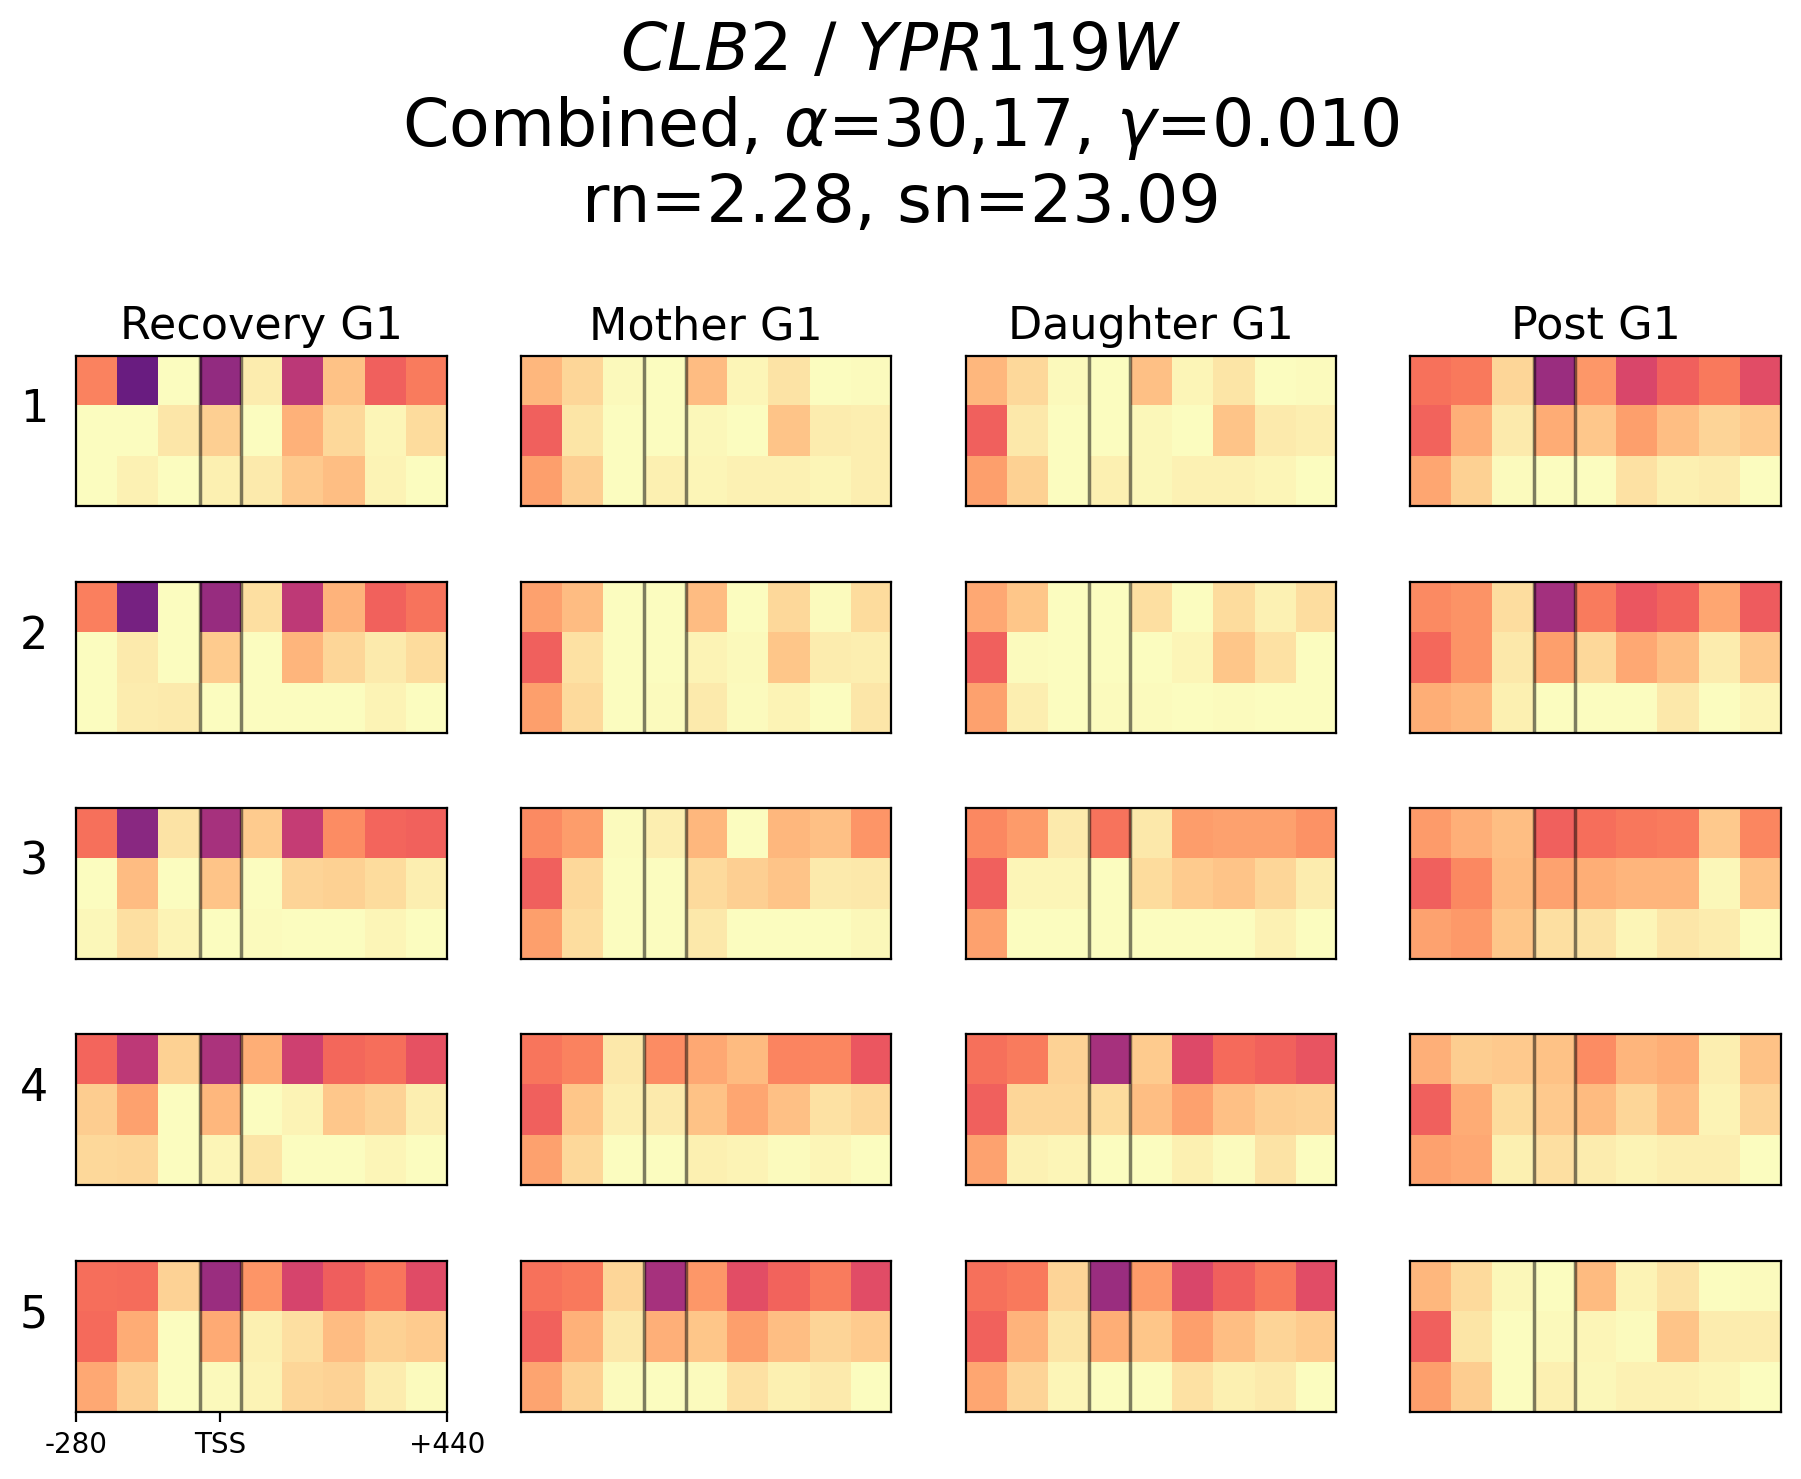

In [49]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped()